#data importing


In [23]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/datasets/diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [24]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


#Data visualization


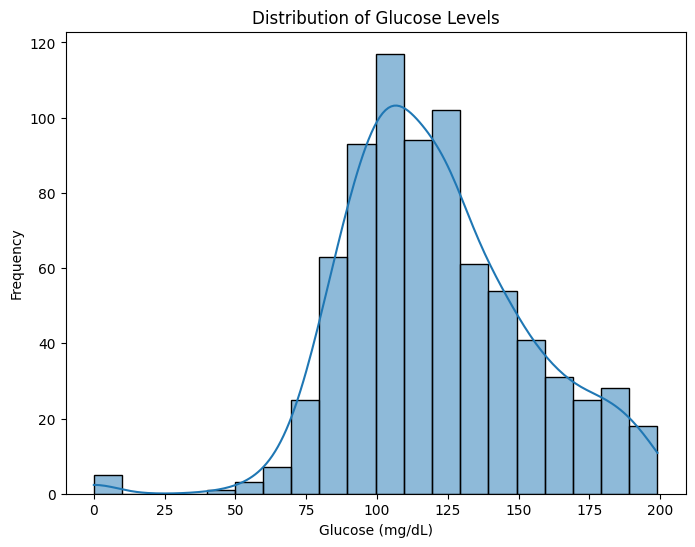

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram of Glucose levels
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Glucose', kde=True, bins=20)
plt.title('Distribution of Glucose Levels')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('Frequency')
plt.show()


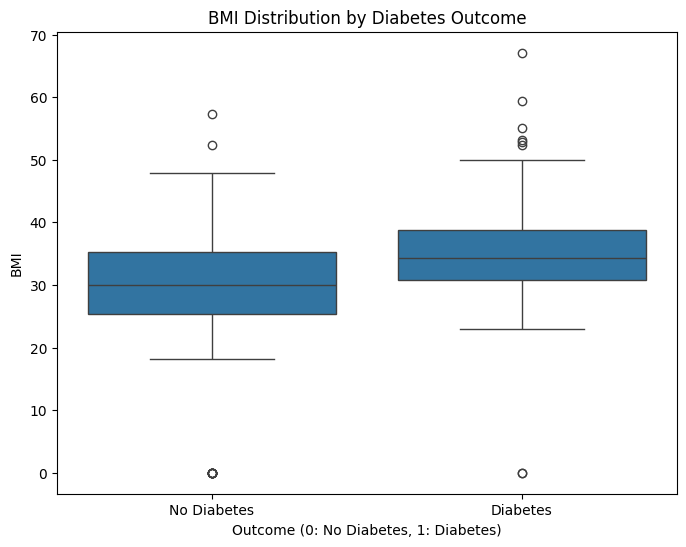

In [26]:
# Box plot of BMI by Outcome
plt.figure(figsize=(8, 6))
sns.boxplot(data=df, x='Outcome', y='BMI')
plt.title('BMI Distribution by Diabetes Outcome')
plt.xlabel('Outcome (0: No Diabetes, 1: Diabetes)')
plt.ylabel('BMI')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.show()



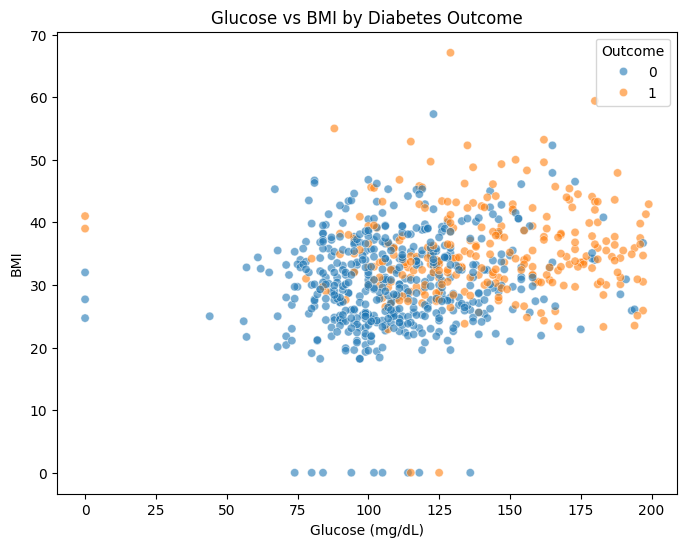

In [27]:
# Scatter plot of Glucose vs BMI
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Glucose', y='BMI', hue='Outcome', alpha=0.6)
plt.title('Glucose vs BMI by Diabetes Outcome')
plt.xlabel('Glucose (mg/dL)')
plt.ylabel('BMI')
plt.show()


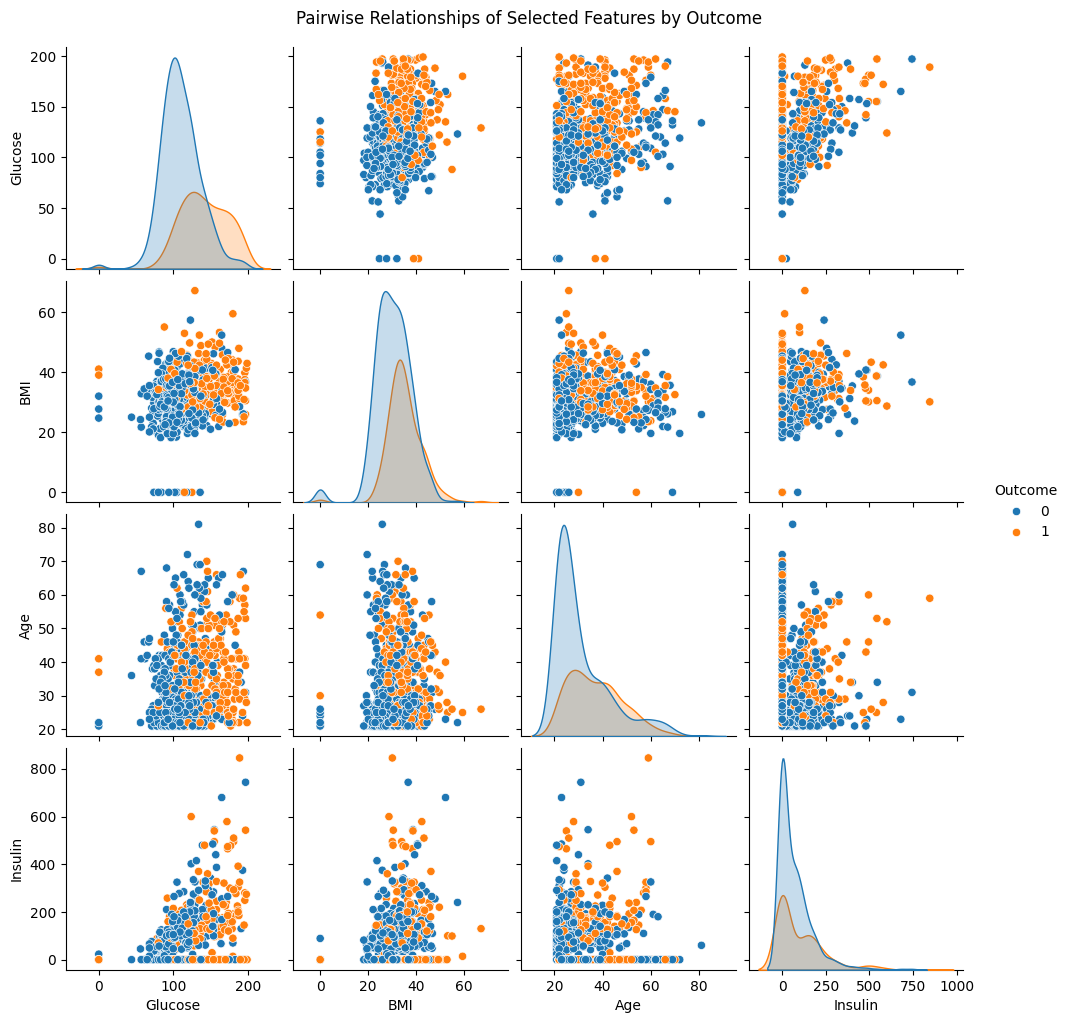

In [28]:
# Pairplot for a subset of features
# This can be computationally intensive for many features
# Let's select a few potentially interesting features
features_for_pairplot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
sns.pairplot(df[features_for_pairplot], hue='Outcome', diag_kind='kde')
plt.suptitle('Pairwise Relationships of Selected Features by Outcome', y=1.02)
plt.show()


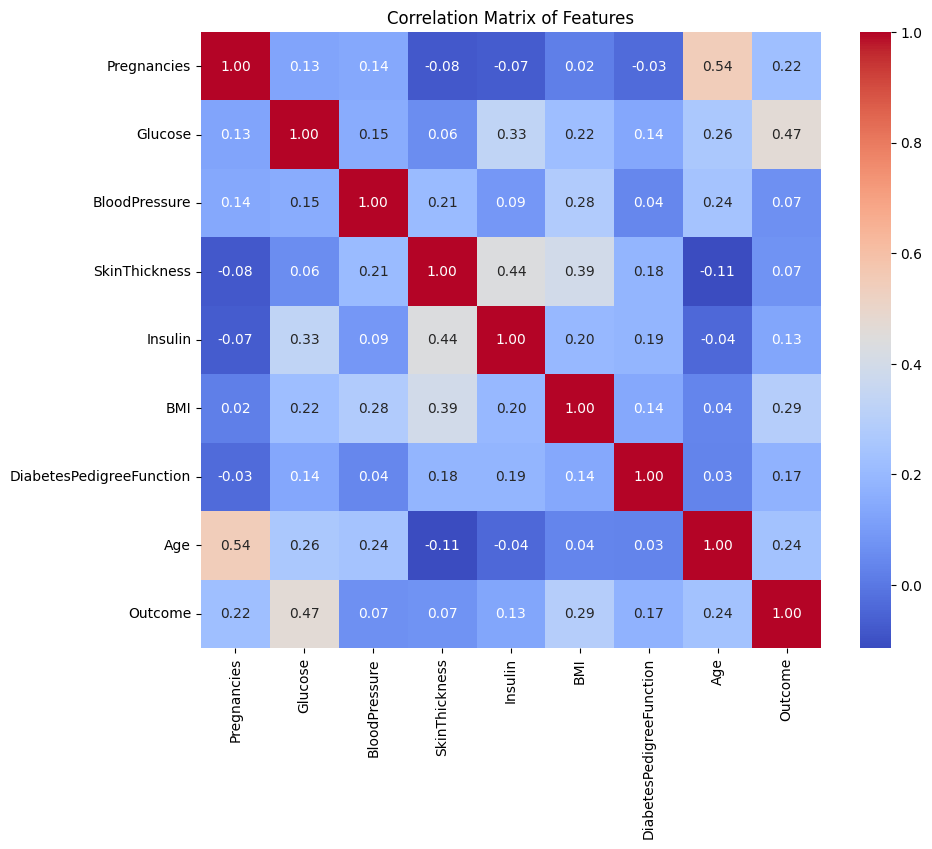

In [29]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features')
plt.show()

#data preprocessing

In [30]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [31]:
#selecting features based on correlation value
abs_correlation_matrix = correlation_matrix.abs()

target_correlation = abs_correlation_matrix['Outcome']
highly_correlated_features = target_correlation[target_correlation > 0.1].index.tolist()

if 'Outcome' in highly_correlated_features:
    highly_correlated_features.remove('Outcome')

print("Features with absolute correlation > 0.1 with the target:")
print(highly_correlated_features)

# Create a new DataFrame with only the highly correlated features and the target
df_selected = df[highly_correlated_features + ['Outcome']]

print("\nDataFrame with selected features:")
print(df_selected.head())

Features with absolute correlation > 0.1 with the target:
['Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']

DataFrame with selected features:
   Pregnancies  Glucose  Insulin   BMI  DiabetesPedigreeFunction  Age  Outcome
0            6      148        0  33.6                     0.627   50        1
1            1       85        0  26.6                     0.351   31        0
2            8      183        0  23.3                     0.672   32        1
3            1       89       94  28.1                     0.167   21        0
4            0      137      168  43.1                     2.288   33        1


In [32]:
df.dtypes

,0
Pregnancies,int64
Glucose,int64
BloodPressure,int64
SkinThickness,int64
Insulin,int64
BMI,float64
DiabetesPedigreeFunction,float64
Age,int64
Outcome,int64


In [33]:
#upsampling target variables to balance
from sklearn.utils import resample

df_majority = df_selected[df_selected.Outcome == 0]
df_minority = df_selected[df_selected.Outcome == 1]

df_minority_upsampled = resample(df_minority,
                                 replace=True,
                                 n_samples=len(df_majority),
                                 random_state=123)

df_balanced = pd.concat([df_majority, df_minority_upsampled])

print("Class counts after upsampling:")
print(df_balanced.Outcome.value_counts())


Class counts after upsampling:
Outcome
0    500
1    500
Name: count, dtype: int64


In [34]:
#scaling feature variables
from sklearn.preprocessing import StandardScaler
import pandas as pd

df_balanced = df_balanced.reset_index(drop=True)

X = df_balanced.drop('Outcome', axis=1)
y = df_balanced['Outcome']

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns)

df_scaled = pd.concat([X_scaled_df, y], axis=1)

print("DataFrame with standardized features:")
print(df_scaled.head())

DataFrame with standardized features:
   Pregnancies   Glucose   Insulin       BMI  DiabetesPedigreeFunction  \
0    -0.894634 -1.230627 -0.719736 -0.783810                 -0.409609   
1    -0.894634 -1.107890  0.065264 -0.587406                 -0.962741   
2     0.250498 -0.279412 -0.719736 -0.914746                 -0.860532   
3     1.681913 -0.310096 -0.719736  0.355335                 -1.061944   
4    -0.035785 -0.463518 -0.719736  0.656488                 -0.890594   

        Age  Outcome  
0 -0.247180        0  
1 -1.125572        0  
2 -0.335019        0  
3 -0.422858        0  
4 -0.335019        0  


In [35]:
#data splitting
from sklearn.model_selection import train_test_split

X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Training features shape: (800, 6)
Testing features shape: (200, 6)
Training target shape: (800,)
Testing target shape: (200,)


#model training and evaluation

In [36]:
#model training and metrics
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


# Separate features (X) and target (y) from the scaled data
X = df_scaled.drop('Outcome', axis=1)
y = df_scaled['Outcome']

# Split the data into training and testing sets (using the scaled data)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Initialize multiple classification models
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'SVM': SVC(probability=True, random_state=42), # probability=True needed for ROC AUC
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Gaussian Naive Bayes': GaussianNB()
}

# Dictionary to store evaluation results
results = {}

# Train and evaluate each model
for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1] # Get probabilities for ROC AUC

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob)

    results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1,
        'ROC AUC': roc_auc
    }
    print(f"{name} - Done")

# Print the results
print("\n--- Model Evaluation Results ---")
for name, metrics in results.items():
    print(f"\n{name}:")
    for metric_name, value in metrics.items():
        print(f"  {metric_name}: {value:.4f}")

# Optional: Find the best model based on a specific metric (e.g., ROC AUC)
best_model_name = max(results, key=lambda k: results[k]['ROC AUC'])
print(f"\nBest model based on ROC AUC: {best_model_name}")


Training Logistic Regression...
Logistic Regression - Done
Training Decision Tree...
Decision Tree - Done
Training Random Forest...
Random Forest - Done
Training Gradient Boosting...
Gradient Boosting - Done
Training SVM...
SVM - Done
Training K-Nearest Neighbors...
K-Nearest Neighbors - Done
Training Gaussian Naive Bayes...
Gaussian Naive Bayes - Done

--- Model Evaluation Results ---

Logistic Regression:
  Accuracy: 0.8000
  Precision: 0.8077
  Recall: 0.8077
  F1 Score: 0.8077
  ROC AUC: 0.8674

Decision Tree:
  Accuracy: 0.9000
  Precision: 0.8559
  Recall: 0.9712
  F1 Score: 0.9099
  ROC AUC: 0.8970

Random Forest:
  Accuracy: 0.9250
  Precision: 0.9009
  Recall: 0.9615
  F1 Score: 0.9302
  ROC AUC: 0.9725

Gradient Boosting:
  Accuracy: 0.8700
  Precision: 0.8482
  Recall: 0.9135
  F1 Score: 0.8796
  ROC AUC: 0.9163

SVM:
  Accuracy: 0.8250
  Precision: 0.8224
  Recall: 0.8462
  F1 Score: 0.8341
  ROC AUC: 0.8949

K-Nearest Neighbors:
  Accuracy: 0.8050
  Precision: 0.7928
  Rec